## Edge Cases Analysis
- **Low Contrast:** Very faint digits might be missed by the Random Forest but recognized by the CNN.
- **Deformations:** If a '7' has a middle bar or a '1' has a base, some models might misclassify them.
- **Overlapping Pixels:** Digits that touch the edge of the 28x28 frame often cause issues for all models.

 Loading MNIST dataset...
 Training CNN model (demo mode: using 2000 samples for speed)...


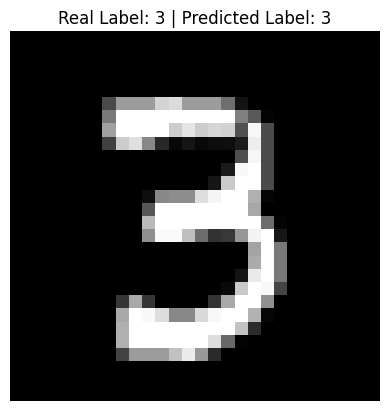

 Demo finished! Predicted digit: 3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from mnist_classifier import MnistClassifier

# 1. Data Loading
print(" Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
x, y = mnist.data.reshape(-1, 28, 28), mnist.target.astype(int)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Model Training (CNN)
# We use the MnistClassifier wrapper, which internally calls the CNN class from models/cnn.py
clf = MnistClassifier(algorithm="cnn")
print(" Training CNN model (demo mode: using 2000 samples for speed)...")
clf.train(x_train[:2000], y_train[:2000])

# 3. Inference on a random test image
idx = np.random.randint(0, len(x_test))
prediction = clf.predict(x_test[idx:idx+1])[0]

# Visualization of the result
plt.imshow(x_test[idx], cmap='gray')
plt.title(f"Real Label: {y_test[idx]} | Predicted Label: {prediction}")
plt.axis('off')
plt.show()

print(f" Demo finished! Predicted digit: {prediction}")